# Extended Data Fig. 5b,c - Quantitative spatial comparison between 3D IHC and 2D ST cell-type distributions

Registered 3D immunohistochemistry (IHC) cell points and 2D spatial-transcriptome (ST) cells are compared for PV, ChAT and TH. ST marker-positive cells are defined by an expression threshold of log2(CPM) > 3.

- ED5b: histograms of the Nearest Neighbor Distance (NND) from 2D ST cells to the corresponding 3D IHC cells, separately for ST marker-positive and marker-negative cells, with median NND values; two-sided Mann-Whitney U test (***P < 0.001).
- ED5c: odds-ratio plot quantifying the spatial association between ST and IHC cell types (odds that an ST marker-positive cell lies near the matching IHC cell type), with 95% CI.

> ED5a is a 3D-reconstruction image panel (not code). Figures/values preserved from the original run; Japanese stripped; verbose logs removed.

## Input files

| File | Content |
|---|---|
| registered 3D IHC cell points (PV / ChAT / TH) | 3D reference cells |
| 2D ST cells (Pvalb / Chat / Th transcripts; log2(CPM) threshold) | ST cells |

## ED5b - Nearest Neighbor Distance (NND): 2D ST -> 3D IHC (marker-positive vs marker-negative; Mann-Whitney)

Data type 'dt_annotation2' defined.
Negative query group will be split into 10 chunks.
Expression threshold for ST positive cells set to: > 3.0
Plots will be saved to: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/

Defined paths for external data.
Loading ST coordinates from: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/abc_atlas_reregistration/cell_joined_with_CCF_invAffined_modified_Affined.csv
ST coordinates loaded successfully.
Loading ST expression data from: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/abc_download_root/gdata_Pvalb_Chat_Th.csv


/home/mitani/my_env/lib64/python3.6/site-packages/IPython/core/interactiveshell.py:3263: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  if (await self.run_code(code, result,  async_=asy)):


ST expression data loaded successfully.
Merging ST coordinates and expression data...
Merge complete. Total cells for analysis: 3260155
Scaling ST SCA coordinates (x50) to µm scale...
ST SCA coordinates scaled to µm.
Attempting to load IHC data...
IHC data loaded successfully.
Classifying ST cells based on expression > 3.0...
  Pvalb: Found 291781 Positive (>3) vs 2968374 Negative (<=3 or NaN) ST cells
  Chat: Found 13509 Positive (>3) vs 3246646 Negative (<=3 or NaN) ST cells
  Th: Found 54197 Positive (>3) vs 3205958 Negative (<=3 or NaN) ST cells

Calculating nearest neighbor distances (Positive)...
Building cKDTree for Pvalb IHC cells (count: 690399)...
Querying cKDTree with Positive ST cells (count: 291781)...
Distances calculated for Pvalb (Positive).
Building cKDTree for Chat IHC cells (count: 64650)...
Querying cKDTree with Positive ST cells (count: 13509)...
Distances calculated for Chat (Positive).
Building cKDTree for Th IHC cells (count: 85802)...
Querying cKDTree with Posi

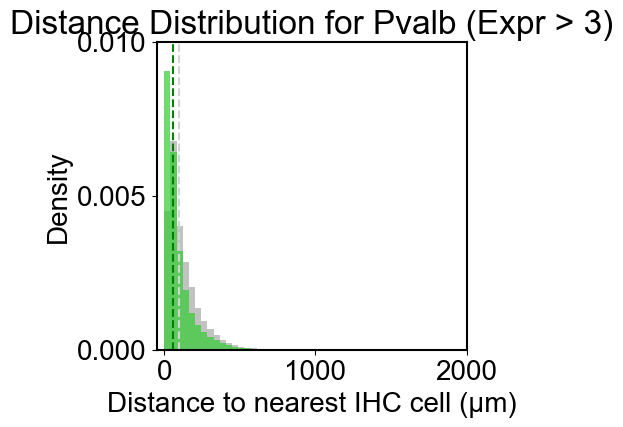

Histogram saved to: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/distance_histogram_Chat_expr_v37.pdf


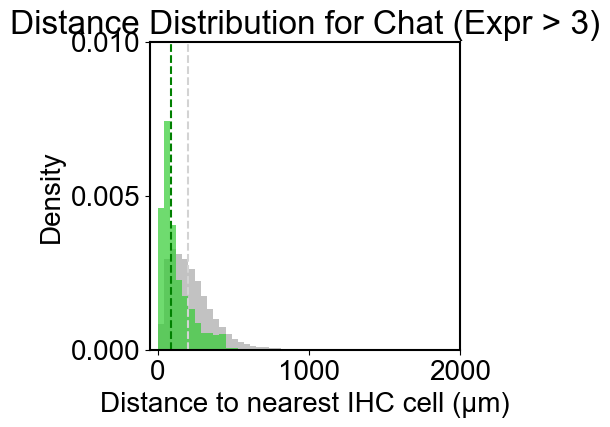

Histogram saved to: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/distance_histogram_Th_expr_v37.pdf


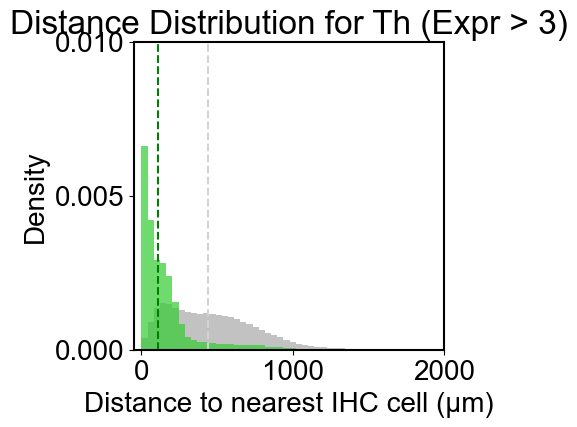

In [1]:
import pandas as pd
import numpy as np
#
from scipy.spatial import cKDTree
from scipy import stats as sp_stats 
import matplotlib.pyplot as plt
import matplotlib #  
import sys
import re 
import gc 

def process_cell_data_v37(): #   v37   (v26  )
    """
    ST (>3) / (<=3   NaN) 
    IHC (NND) 
    (v16 NND )
    """
    try:
        #
        dt_annotation2 = np.dtype([
            ('stitched_x', 'f4'), ('stitched_y', 'f4'), ('stitched_z', 'f4'),
            ('mapped_x', 'f4'), ('mapped_y', 'f4'), ('mapped_z', 'f4'),
            ('SCA_x', 'f4'), ('SCA_y', 'f4'), ('SCA_z', 'f4'),
            ('atlas_id', 'u2')
        ])
        print("Data type 'dt_annotation2' defined.")

        N_SPLITS = 10 
        EXPRESSION_THRESHOLD = 3.0 
        
        print(f"Negative query group will be split into {N_SPLITS} chunks.")
        print(f"Expression threshold for ST positive cells set to: > {EXPRESSION_THRESHOLD}")

        #
        path_chat = "/export3/Imaging/CUBIC_Cloud_data/CHAT001/SCA_registered_cell_coordinates_ver2_2.bin"
        path_pv = "/export3/Imaging/CUBIC_Cloud_data/PV001/SCA_registered_cell_coordinates_ver2_2.bin"
        path_th = "/export3/Imaging/CUBIC_Cloud_data/TH001/SCA_registered_cell_coordinates_ver2_2.bin"
        
        path_st_cells = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/abc_atlas_reregistration/cell_joined_with_CCF_invAffined_modified_Affined.csv"
        path_st_expression = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/abc_download_root/gdata_Pvalb_Chat_Th.csv"
        
        pdf_save_directory = ""
        print(f"Plots will be saved to: {pdf_save_directory}")

        print("\nDefined paths for external data.")
        np.random.seed(42)

        #
        print(f"Loading ST coordinates from: {path_st_cells}")
        #
        st_columns_needed = ['x_SCA', 'y_SCA', 'z_SCA'] 
        cell_joined = pd.read_csv(path_st_cells, index_col=0, usecols=['cell_label'] + st_columns_needed)
        print("ST coordinates loaded successfully.")

        print(f"Loading ST expression data from: {path_st_expression}")
        gdata = pd.read_csv(path_st_expression, index_col=0) 
        print("ST expression data loaded successfully.")
        
        #
        print("Merging ST coordinates and expression data...")
        cell_joined_merged = cell_joined.join(gdata, how='inner')
        print(f"Merge complete. Total cells for analysis: {len(cell_joined_merged)}")
        
        markers_to_check = ["Pvalb", "Chat", "Th"] # Sst  
        
        if not all(marker in cell_joined_merged.columns for marker in markers_to_check):
            print(f"--- ERROR: Missing marker columns in merged data ---")
            return "Processing halted."

        del cell_joined, gdata 
        gc.collect()

        #
        print("Scaling ST SCA coordinates (x50) to µm scale...")
        cell_joined_merged['x_SCA'] = cell_joined_merged['x_SCA'] * 50.0
        cell_joined_merged['y_SCA'] = cell_joined_merged['y_SCA'] * 50.0
        cell_joined_merged['z_SCA'] = cell_joined_merged['z_SCA'] * 50.0
        print("ST SCA coordinates scaled to µm.")

        #
        print("Attempting to load IHC data...")
        ihc_data_map = {
            'Chat': np.fromfile(path_chat, dtype=dt_annotation2),
            'Pvalb': np.fromfile(path_pv, dtype=dt_annotation2),
            'Th': np.fromfile(path_th, dtype=dt_annotation2)
            #
        }
        print("IHC data loaded successfully.")

        #
        print(f"Classifying ST cells based on expression > {EXPRESSION_THRESHOLD}...")
        
        st_cell_groups_positive = {} 
        st_cell_groups_negative = {} 
        
        for marker_name in markers_to_check:
            is_positive = (cell_joined_merged[marker_name] > EXPRESSION_THRESHOLD)
            is_negative = (cell_joined_merged[marker_name] <= EXPRESSION_THRESHOLD) | (cell_joined_merged[marker_name].isna())
            
            st_cell_groups_positive[marker_name] = cell_joined_merged[is_positive]
            st_cell_groups_negative[marker_name] = cell_joined_merged[is_negative] 
            print(f"  {marker_name}: Found {len(st_cell_groups_positive[marker_name])} Positive (>3) vs {len(st_cell_groups_negative[marker_name])} Negative (<=3 or NaN) ST cells")

        #
        print("\nCalculating nearest neighbor distances (Positive)...")
        
        all_distances_positive = {} 
        kdtree_map = {}           
        ihc_coords_count = {}     

        for marker_name in markers_to_check:
            st_cells = st_cell_groups_positive[marker_name]
            ihc_cells_np = ihc_data_map.get(marker_name)
            if ihc_cells_np is None:
                print(f"Warning: No IHC data found for {marker_name}. Skipping.")
                all_distances_positive[marker_name] = np.array([])
                continue
            
            valid_ihc_mask = (ihc_cells_np['SCA_x'] != 0) | (ihc_cells_np['SCA_y'] != 0) | (ihc_cells_np['SCA_z'] != 0)
            ihc_coords = np.vstack([
                ihc_cells_np['SCA_x'][valid_ihc_mask], 
                ihc_cells_np['SCA_y'][valid_ihc_mask], 
                ihc_cells_np['SCA_z'][valid_ihc_mask]
            ]).T
            ihc_coords_count[marker_name] = len(ihc_coords) 
            
            if len(ihc_coords) == 0:
                 print(f"Warning: No valid (non-zero) IHC coordinates found for {marker_name}. Skipping.")
                 all_distances_positive[marker_name] = np.array([])
                 continue
            
            print(f"Building cKDTree for {marker_name} IHC cells (count: {len(ihc_coords)})...")
            kdtree = cKDTree(ihc_coords)
            kdtree_map[marker_name] = kdtree
            
            if len(st_cells) == 0:
                print(f"Warning: No Positive ST cells for {marker_name}.")
                all_distances_positive[marker_name] = np.array([])
                continue
                
            st_coords = st_cells[['x_SCA', 'y_SCA', 'z_SCA']].values
            print(f"Querying cKDTree with Positive ST cells (count: {len(st_coords)})...")
            distances, _ = kdtree.query(st_coords, k=1, n_jobs=-1) 
            all_distances_positive[marker_name] = distances
            print(f"Distances calculated for {marker_name} (Positive).")

        #
        print("\nCalculating nearest neighbor distances (Negative All - Split)...")
        all_distances_negative_all = {} 
        
        for marker_name in markers_to_check:
            positive_distances = all_distances_positive.get(marker_name, np.array([]))
            kdtree_to_use = kdtree_map.get(marker_name) 
            st_negative_cells = st_cell_groups_negative.get(marker_name) 

            if kdtree_to_use is None or st_negative_cells is None or len(st_negative_cells) == 0:
                print(f"Skipping negative calculation for {marker_name} (no KDTree or no negative cells).")
                all_distances_negative_all[marker_name] = np.array([])
                continue
            
            st_coords_negative_all = st_negative_cells[['x_SCA', 'y_SCA', 'z_SCA']].values
            print(f"Total Negative ST cells to query for {marker_name}: {len(st_coords_negative_all)}")
            
            negative_splits_coords = np.array_split(st_coords_negative_all, N_SPLITS)
            distances_split_list = []
            
            print(f"Querying cKDTree with Negative All ST cells (in {N_SPLITS} chunks)...")
            for i, split_coords in enumerate(negative_splits_coords):
                print(f"  Processing chunk {i+1}/{N_SPLITS} (size: {len(split_coords)})...")
                distances_split, _ = kdtree_to_use.query(split_coords, k=1, n_jobs=-1) 
                distances_split_list.append(distances_split)
                del distances_split
                gc.collect()

            all_distances_negative_all[marker_name] = np.concatenate(distances_split_list)
            print(f"Distances calculated for {marker_name} (Negative All).")
            
            del st_coords_negative_all, negative_splits_coords, distances_split_list
            gc.collect()

        #
        print("\n--- Summary of Nearest Neighbor Distances (Positive vs Negative All) ---")
        summary_stats = []
        marker_order_list = list(markers_to_check) 

        for marker_name in markers_to_check:
            distances_positive = all_distances_positive.get(marker_name, np.array([]))
            distances_negative = all_distances_negative_all.get(marker_name, np.array([]))

            p_value = np.nan
            if len(distances_positive) > 0 and len(distances_negative) > 0:
                try:
                    stat, p_value = sp_stats.mannwhitneyu(distances_positive, distances_negative, alternative='less')
                except ValueError as e:
                    print(f"Warning: Mann-Whitney U test failed for {marker_name}. Error: {e}")
                    p_value = 1.0 

            stats = {
                'Marker': marker_name,
                'ST_Cell_Count_Positive': len(distances_positive),
                'ST_Cell_Count_Negative_All': len(distances_negative), 
                'IHC_Cell_Count_Used': ihc_coords_count.get(marker_name, 0),
                'Mean_Distance_Positive': np.mean(distances_positive) if len(distances_positive) > 0 else np.nan,
                'Median_Distance_Positive': np.median(distances_positive) if len(distances_positive) > 0 else np.nan,
                'Mean_Distance_Negative_All': np.mean(distances_negative) if len(distances_negative) > 0 else np.nan, 
                'Median_Distance_Negative_All': np.median(distances_negative) if len(distances_negative) > 0 else np.nan, 
                'P_Value (Positive < Negative)': p_value
            }
            summary_stats.append(stats)

            print(f"\nStats for {marker_name}:")
            print(f"  ST Positive Cell Count: {stats['ST_Cell_Count_Positive']}")
            print(f"  ST Negative All Count: {stats['ST_Cell_Count_Negative_All']}") 
            print(f"  IHC Cell Count (used, non-zero): {stats['IHC_Cell_Count_Used']}")
            print(f"  Mean Distance (Positive): {stats['Mean_Distance_Positive']:.2f} µm") 
            print(f"  Mean Distance (Negative All): {stats['Mean_Distance_Negative_All']:.2f} µm") 
            print(f"  Median Distance (Positive): {stats['Median_Distance_Positive']:.2f} µm") 
            print(f"  Median Distance (Negative All): {stats['Median_Distance_Negative_All']:.2f} µm") 
            print(f"  Mann-Whitney U P-Value (Positive < Negative): {stats['P_Value (Positive < Negative)']:.2e}") 

        df_summary = pd.DataFrame(summary_stats)
        summary_filename = "st_to_ihc_nearest_neighbor_summary_v37.csv" # v37  
        df_summary.to_csv( f"{pdf_save_directory}{summary_filename}", index=False)
        print(f"\nSummary statistics saved to: {summary_filename}")

        for marker_name, distances in all_distances_positive.items():
            if len(distances) > 0:
                pd.DataFrame(distances, columns=['Distance_Positive_um']).to_csv(f"distances_st_to_ihc_{marker_name}_positive_v37.csv", index=False)
        for marker_name, distances in all_distances_negative_all.items(): 
            if len(distances) > 0:
                pd.DataFrame(distances, columns=['Distance_Negative_All_um']).to_csv(f"distances_st_to_ihc_{marker_name}_negative_all_v37.csv", index=False) 

        #
        print("\nGenerating histograms (v37)...")
        
        #
        print("Setting Matplotlib font to Arial for PDF export...")
        plt.style.use('default') 
        matplotlib.rcParams['pdf.fonttype'] = 42
        matplotlib.rcParams['ps.fonttype'] = 42
        matplotlib.rcParams['font.family'] = 'Arial'
        matplotlib.rcParams['axes.linewidth'] = 1.5
        matplotlib.rcParams['font.size'] = 20 
        
        for marker_name in markers_to_check:
            distances_positive = all_distances_positive.get(marker_name, np.array([]))
            distances_negative = all_distances_negative_all.get(marker_name, np.array([])) 

            if len(distances_positive) == 0 or len(distances_negative) == 0:
                print(f"Skipping histogram for {marker_name} (no data).")
                continue

            plt.figure(figsize=(4, 4))
            
            plot_xlim = 2000
            bins = np.linspace(0, plot_xlim, 50) 

            #
            plt.hist(distances_negative, bins=bins, color='darkgrey', edgecolor='None', 
                     alpha=0.7, label=f'Negative (<=3 or NaN) (n={len(distances_negative)})', 
                     density=True) 
            
            plt.hist(distances_positive, bins=bins, color='limegreen', edgecolor='None', 
                     alpha=0.7, label=f'Positive (>3) (n={len(distances_positive)})', 
                     density=True) 

            #
            stats = next((item for item in summary_stats if item["Marker"] == marker_name), None)
            if stats:
                median_pos = stats['Median_Distance_Positive']
                median_neg = stats['Median_Distance_Negative_All']
                
                plt.axvline(median_pos, color='green', linestyle='--', linewidth=1.5, label=f'Median (Pos): {median_pos:.2f} µm')
                plt.axvline(median_neg, color='lightgrey', linestyle='--', linewidth=1.5, label=f'Median (Neg): {median_neg:.2f} µm')
                
                p_val_text = f"P (Pos < Neg) = {stats['P_Value (Positive < Negative)']:.2e}"
                #plt.text(0.95, 0.95, p_val_text, transform=plt.gca().transAxes, ha='right', va='top', bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8), fontsize=8)

            #plt.legend(fontsize=8) 
            plt.title(f'Distance Distribution for {marker_name} (Expr > 3)')
            plt.xlabel('Distance to nearest IHC cell (µm)') 
            plt.ylabel('Density') 
            
            plt.xlim(-50, 2000)
            plt.ylim(0, 0.010)
            
            plt.xticks([0,1000, 2000])
            plt.yticks([0.000,0.005, 0.010])
            
            
            hist_filename = f'{pdf_save_directory}distance_histogram_{marker_name}_expr_v37.pdf' # v37  

            plt.savefig(
                hist_filename,
                transparent=True, 
                dpi=300, 
                bbox_inches='tight', 
                pad_inches=0.1
            )
            
            print(f"Histogram saved to: {hist_filename}")
            plt.show() 
            
            plt.close() 

    except FileNotFoundError as e:
        print(f"\n--- PROCESSING HALTED: File Not Found ---")
        print(f"Error: {e}")
    except KeyError as e:
        print(f"\n--- PROCESSING HALTED: Key Error ---")
        print(f"Error: A required column was not found: {e}")
    except Exception as e:
        print(f"\n--- PROCESSING HALTED: Unexpected Error ---")
        print(f"An unexpected error occurred: {e}")
        import traceback
        traceback.print_exc()

    return "Processing function (v37) execution finished."

#
process_cell_data_v37()

## ED5c - Odds ratio for spatial association between ST and IHC cell types (95% CI)

Data type 'dt_annotation2' defined.
Enrichment radius set to: 100 µm
Query (Negative ST Cells) will be split into 10 chunks.
Expression threshold for ST positive cells set to: > 3.0
Plots will be saved to: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/

Defined paths for external data.
Loading ST coordinates from: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/abc_atlas_reregistration/cell_joined_with_CCF_invAffined_modified_Affined.csv
ST coordinates loaded successfully.
Loading ST expression data from: /export3/Imaging/ds4_Data5/Neurology_project_data_archive/abc_download_root/gdata_Pvalb_Chat_Th.csv


/home/mitani/my_env/lib64/python3.6/site-packages/IPython/core/interactiveshell.py:3263: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  if (await self.run_code(code, result,  async_=asy)):


ST expression data loaded successfully.
Merging ST coordinates and expression data...
Merge complete. Total cells for analysis: 3260155
Scaling ST SCA coordinates (x50) to µm scale...
ST SCA coordinates scaled to µm.
Attempting to load IHC data...
IHC data loaded successfully.
Classifying ST cells based on expression > 3.0...
  Pvalb: Found 291781 Positive (>3) vs 2968374 Negative (<=3 or NaN) ST cells
  Chat: Found 13509 Positive (>3) vs 3246646 Negative (<=3 or NaN) ST cells
  Th: Found 54197 Positive (>3) vs 3205958 Negative (<=3 or NaN) ST cells

Calculating neighbor counts (Positive)...
Building cKDTree for Pvalb IHC cells (count: 690399)...
Querying cKDTree with Positive ST cells (count: 291781)...
Counts calculated for Pvalb (Positive).
Building cKDTree for Chat IHC cells (count: 64650)...
Querying cKDTree with Positive ST cells (count: 13509)...
Counts calculated for Chat (Positive).
Building cKDTree for Th IHC cells (count: 85802)...
Querying cKDTree with Positive ST cells (co

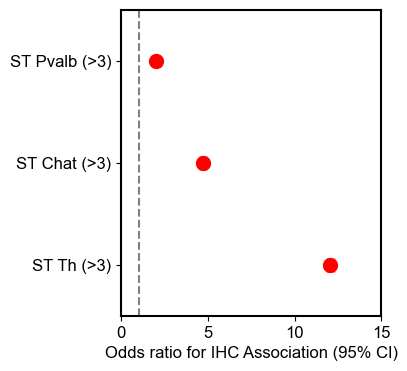

In [2]:
import pandas as pd
import numpy as np
#
from scipy.spatial import cKDTree
from scipy import stats as sp_stats 
import matplotlib.pyplot as plt
import matplotlib #  
import sys
import re 
import gc 
#
import statsmodels.stats.multitest as multitest
from statsmodels.stats.contingency_tables import Table2x2

def process_cell_data_v36(): #   v36  
    """
    ST / (r=100um) IHC (1 or 0) 
     
    (v35  + v36 X (0-15) (0,5,10,15) )
    """
    try:
        #
        
        #
        dt_annotation2 = np.dtype([
            ('stitched_x', 'f4'), ('stitched_y', 'f4'), ('stitched_z', 'f4'),
            ('mapped_x', 'f4'), ('mapped_y', 'f4'), ('mapped_z', 'f4'),
            ('SCA_x', 'f4'), ('SCA_y', 'f4'), ('SCA_z', 'f4'),
            ('atlas_id', 'u2')
        ])
        print("Data type 'dt_annotation2' defined.")
        N_SPLITS = 10 
        RADIUS = 100  
        EXPRESSION_THRESHOLD = 3.0 
        print(f"Enrichment radius set to: {RADIUS} µm")
        print(f"Query (Negative ST Cells) will be split into {N_SPLITS} chunks.")
        print(f"Expression threshold for ST positive cells set to: > {EXPRESSION_THRESHOLD}")

        #
        path_chat = "/export3/Imaging/CUBIC_Cloud_data/CHAT001/SCA_registered_cell_coordinates_ver2_2.bin"
        path_pv = "/export3/Imaging/CUBIC_Cloud_data/PV001/SCA_registered_cell_coordinates_ver2_2.bin"
        path_th = "/export3/Imaging/CUBIC_Cloud_data/TH001/SCA_registered_cell_coordinates_ver2_2.bin"
        path_st_cells = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/abc_atlas_reregistration/cell_joined_with_CCF_invAffined_modified_Affined.csv"
        path_st_expression = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/abc_download_root/gdata_Pvalb_Chat_Th.csv"
        pdf_save_directory = ""
        print(f"Plots will be saved to: {pdf_save_directory}")
        print("\nDefined paths for external data.")
        np.random.seed(42)

        #
        print(f"Loading ST coordinates from: {path_st_cells}")
        st_columns_needed = ['x_SCA', 'y_SCA', 'z_SCA'] 
        cell_joined = pd.read_csv(path_st_cells, index_col=0, usecols=['cell_label'] + st_columns_needed)
        print("ST coordinates loaded successfully.")
        print(f"Loading ST expression data from: {path_st_expression}")
        gdata = pd.read_csv(path_st_expression, index_col=0) 
        print("ST expression data loaded successfully.")
        
        #
        print("Merging ST coordinates and expression data...")
        cell_joined_merged = cell_joined.join(gdata, how='inner')
        print(f"Merge complete. Total cells for analysis: {len(cell_joined_merged)}")
        
        markers_to_check = ["Pvalb", "Chat", "Th"]
        
        if not all(marker in cell_joined_merged.columns for marker in markers_to_check):
            print(f"--- ERROR: Missing marker columns in merged data ---")
            return "Processing halted."
        del cell_joined, gdata 
        gc.collect()

        #
        print("Scaling ST SCA coordinates (x50) to µm scale...")
        cell_joined_merged['x_SCA'] = cell_joined_merged['x_SCA'] * 50.0
        cell_joined_merged['y_SCA'] = cell_joined_merged['y_SCA'] * 50.0
        cell_joined_merged['z_SCA'] = cell_joined_merged['z_SCA'] * 50.0
        print("ST SCA coordinates scaled to µm.")

        #
        print("Attempting to load IHC data...")
        ihc_data_map = {
            'Chat': np.fromfile(path_chat, dtype=dt_annotation2),
            'Pvalb': np.fromfile(path_pv, dtype=dt_annotation2),
            'Th': np.fromfile(path_th, dtype=dt_annotation2)
        }
        print("IHC data loaded successfully.")

        #
        print(f"Classifying ST cells based on expression > {EXPRESSION_THRESHOLD}...")
        st_cell_groups_positive = {} 
        st_cell_groups_negative = {} 
        
        for marker_name in markers_to_check:
            is_positive = (cell_joined_merged[marker_name] > EXPRESSION_THRESHOLD)
            is_negative = (cell_joined_merged[marker_name] <= EXPRESSION_THRESHOLD) | (cell_joined_merged[marker_name].isna())
            st_cell_groups_positive[marker_name] = cell_joined_merged[is_positive]
            st_cell_groups_negative[marker_name] = cell_joined_merged[is_negative] 
            print(f"  {marker_name}: Found {len(st_cell_groups_positive[marker_name])} Positive (>3) vs {len(st_cell_groups_negative[marker_name])} Negative (<=3 or NaN) ST cells")

        #
        print("\nCalculating neighbor counts (Positive)...")
        all_counts_positive = {} 
        kdtree_map = {}           
        ihc_coords_count = {}     
        
        for marker_name in markers_to_check:
            st_cells = st_cell_groups_positive[marker_name]
            ihc_cells_np = ihc_data_map.get(marker_name)
            if ihc_cells_np is None:
                print(f"Warning: No IHC data found for {marker_name}. Skipping.")
                all_counts_positive[marker_name] = np.array([])
                continue
            valid_ihc_mask = (ihc_cells_np['SCA_x'] != 0) | (ihc_cells_np['SCA_y'] != 0) | (ihc_cells_np['SCA_z'] != 0)
            ihc_coords = np.vstack([
                ihc_cells_np['SCA_x'][valid_ihc_mask], 
                ihc_cells_np['SCA_y'][valid_ihc_mask], 
                ihc_cells_np['SCA_z'][valid_ihc_mask]
            ]).T
            ihc_coords_count[marker_name] = len(ihc_coords) 
            if len(ihc_coords) == 0:
                 print(f"Warning: No valid (non-zero) IHC coordinates found for {marker_name}. Skipping.")
                 all_counts_positive[marker_name] = np.array([])
                 continue
            print(f"Building cKDTree for {marker_name} IHC cells (count: {len(ihc_coords)})...")
            kdtree = cKDTree(ihc_coords)
            kdtree_map[marker_name] = kdtree
            if len(st_cells) == 0:
                print(f"Warning: No Positive ST cells for {marker_name}.")
                all_counts_positive[marker_name] = np.array([])
                continue
            st_coords = st_cells[['x_SCA', 'y_SCA', 'z_SCA']].values
            print(f"Querying cKDTree with Positive ST cells (count: {len(st_coords)})...")
            neighbors_list = kdtree.query_ball_point(st_coords, r=RADIUS, n_jobs=-1) 
            counts = np.array([len(n) for n in neighbors_list])
            all_counts_positive[marker_name] = counts
            print(f"Counts calculated for {marker_name} (Positive).")

        #
        print("\nCalculating neighbor counts (Negative All - Split)...")
        all_counts_negative_all = {} 
        
        for marker_name in markers_to_check:
            positive_counts = all_counts_positive.get(marker_name, np.array([])) 
            kdtree_to_use = kdtree_map.get(marker_name) 
            st_negative_cells = st_cell_groups_negative.get(marker_name) 
            if kdtree_to_use is None or st_negative_cells is None or len(st_negative_cells) == 0:
                print(f"Skipping negative calculation for {marker_name} (no KDTree or no negative cells).")
                all_counts_negative_all[marker_name] = np.array([])
                continue
            st_coords_negative_all = st_negative_cells[['x_SCA', 'y_SCA', 'z_SCA']].values
            print(f"Total Negative ST cells to query for {marker_name}: {len(st_coords_negative_all)}")
            negative_splits_coords = np.array_split(st_coords_negative_all, N_SPLITS)
            counts_split_list = []
            print(f"Querying cKDTree with Negative All ST cells (in {N_SPLITS} chunks)...")
            for i, split_coords in enumerate(negative_splits_coords):
                print(f"  Processing chunk {i+1}/{N_SPLITS} (size: {len(split_coords)})...")
                neighbors_list_split = kdtree_to_use.query_ball_point(split_coords, r=RADIUS, n_jobs=-1) 
                counts_split = np.array([len(n) for n in neighbors_list_split])
                counts_split_list.append(counts_split)
                del neighbors_list_split, counts_split
                gc.collect()
            all_counts_negative_all[marker_name] = np.concatenate(counts_split_list)
            print(f"Counts calculated for {marker_name} (Negative All).")
            del st_coords_negative_all, negative_splits_coords, counts_split_list
            gc.collect()

        #
        print("\n--- Summary of Enrichment Analysis (Positive vs Negative All) ---")
        summary_stats = []
        marker_order_list = list(markers_to_check) 
        p_values_for_fdr = [] 

        for marker_name in markers_to_check:
            counts_positive = all_counts_positive.get(marker_name, np.array([]))
            counts_negative = all_counts_negative_all.get(marker_name, np.array([]))

            odds_ratio = np.nan
            p_value = np.nan
            ci_low, ci_high = np.nan, np.nan
            a, b, c, d = 0, 0, 0, 0 
            
            if len(counts_positive) > 0:
                a = np.sum(counts_positive > 0)
                b = np.sum(counts_positive == 0) 
            if len(counts_negative) > 0:
                c = np.sum(counts_negative > 0) 
                d = np.sum(counts_negative == 0)
                
            contingency_table = np.array([[a, b], [c, d]])
            
            print(f"\nContingency Table for {marker_name}:")
            print(f"                 | IHC Nearby (>=1) | IHC Nearby (0) | Total")
            print(f"-----------------|------------------|----------------|-------")
            print(f"ST Positive (>3) | {a:<16} | {b:<14} | {a+b}")
            print(f"ST Negative (<=3)| {c:<16} | {d:<14} | {c+d}")
            
            if (a+b == 0) or (c+d == 0) or (a+c == 0) or (b+d == 0):
                print("  Skipping Fisher test: Empty group found.")
            else:
                try:
                    odds_ratio, p_value = sp_stats.fisher_exact(contingency_table, alternative='two-sided')
                    table = Table2x2(contingency_table)
                    ci = table.oddsratio_confint()
                    ci_low, ci_high = ci[0], ci[1]
                except ValueError as e:
                    print(f"Warning: Fisher test failed for {marker_name}. Error: {e}")
                    p_value = 1.0 

            p_values_for_fdr.append(p_value) 

            stats = {
                'Marker': marker_name,
                'Odds_Ratio': odds_ratio,
                'P_Value (Fisher, two-sided)': p_value,
                'CI_Low (95%)': ci_low,
                'CI_High (95%)': ci_high,
                'Percent_Positive_Nearby': (a / (a + b)) * 100 if (a + b) > 0 else 0,
                'Percent_Negative_Nearby': (c / (c + d)) * 100 if (c + d) > 0 else 0
            }
            summary_stats.append(stats)

            print(f"  ST Positive (>3): {stats['Percent_Positive_Nearby']:.2f}% have IHC cell nearby.")
            print(f"  ST Negative (<=3): {stats['Percent_Negative_Nearby']:.2f}% have IHC cell nearby.")
            print(f"  Odds Ratio: {stats['Odds_Ratio']:.2f} (95% CI: {stats['CI_Low (95%)']:.2f} - {stats['CI_High (95%)']:.2f})") 
            print(f"  Fisher's Exact P-Value (two-sided): {stats['P_Value (Fisher, two-sided)']:.2e}") 

        #
        print("\nApplying FDR (Benjamini-Hochberg) correction...")
        reject, pvals_corrected, _, _ = multitest.multipletests(p_values_for_fdr, method='fdr_bh')
        
        for i, stats in enumerate(summary_stats):
            stats['P_Value_FDR_Corrected'] = pvals_corrected[i]
            print(f"  {stats['Marker']}: Corrected P-Value = {pvals_corrected[i]:.2e}")

        df_summary = pd.DataFrame(summary_stats)
        summary_filename = "st_to_ihc_enrichment_summary_v36.csv" # v36  
        df_summary.to_csv( f"{pdf_save_directory}{summary_filename}", index=False)
        print(f"\nEnrichment Summary statistics saved to: {summary_filename}")


        #
        print("\nGenerating Odds Ratio plots...")
        
        #
        print("Setting Matplotlib font to Arial for PDF export...")
        plt.style.use('default') 
        matplotlib.rcParams['pdf.fonttype'] = 42
        matplotlib.rcParams['ps.fonttype'] = 42
        matplotlib.rcParams['font.family'] = 'Arial'
        matplotlib.rcParams['axes.linewidth'] = 1.5
        matplotlib.rcParams['font.size'] = 12 
        
        n_markers = len(summary_stats)
        
        #
        y_labels = [f"ST {s['Marker']} (>3)" for s in reversed(summary_stats)]
        
        fig, ax = plt.subplots(figsize=(4, n_markers * 1.2))

        #
        for i, stats in enumerate(reversed(summary_stats)): 
            odds_ratio = stats['Odds_Ratio']
            ci_low = stats['CI_Low (95%)']
            ci_high = stats['CI_High (95%)']
            fdr_p = stats['P_Value_FDR_Corrected']
            
            xerr = [[odds_ratio - ci_low], [ci_high - odds_ratio]]
            
            color = 'red' if odds_ratio > 1 else 'blue'
            color = 'gray' if fdr_p >= 0.05 else color
            
            ax.errorbar(odds_ratio, i, xerr=xerr,
                        fmt='o', color=color, markersize=10, capsize=5)

        ax.axvline(1, color='grey', linestyle='--') 
        
        #
        ax.set_xlim(0, 15) 
        ax.set_xticks([0, 5, 10, 15])

        ax.set_ylim(-0.5, n_markers - 0.5)
        ax.set_yticks(range(n_markers))
        
        ax.set_yticklabels(y_labels)
        ax.set_xlabel('Odds ratio for IHC Association (95% CI)')
        
        plt.tight_layout()
        plt.subplots_adjust(left=0.3, right=0.95, top=0.95, bottom=0.1)

        plot_filename = f'{pdf_save_directory}enrichment_odds_ratio_plot_expr_v36.pdf' # v36  

        plt.savefig(
            plot_filename,
            transparent=True, 
            dpi=300, 
            bbox_inches='tight', 
            pad_inches=0.1
        )
        
        print(f"Odds Ratio plot saved to: {plot_filename}")
        plt.show() 
        plt.close() 

    except FileNotFoundError as e:
        print(f"\n--- PROCESSING HALTED: File Not Found ---")
        print(f"Error: {e}")
    except KeyError as e:
        print(f"\n--- PROCESSING HALTED: Key Error ---")
        print(f"Error: A required column was not found: {e}")
    except ImportError as e:
        print(f"\n--- PROCESSING HALTED: ImportError ---")
        print(f"Error: {e}. 'statsmodels'  ")
        print(" (pip install statsmodels)")
    except Exception as e:
        print(f"\n--- PROCESSING HALTED: Unexpected Error ---")
        print(f"An unexpected error occurred: {e}")
        import traceback
        traceback.print_exc()

    return "Processing function (v36) execution finished."

#
process_cell_data_v36()